#
>setting enviornment

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PALETTE = ['#F76587', '#D96B47', '#A6771D', '#697C1D', '#1C793D', '#006F61']
sns.set_palette(PALETTE)

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print(train.shape, test.shape)

(45000, 15) (5000, 15)


#Pre-processing

Before starting, we are ensuring that the test and train dataset do *not* have any overlaps, as any overlap between them can make it difficult to re-evaluate future results, and it can even cause inflation of accuracy.

In [12]:
print("Train:", train.shape)
print("Test:", test.shape)
print("Any overlap in Student_ID?",
      set(train['Student_ID']).intersection(set(test['Student_ID'])))

Train: (45000, 15)
Test: (5000, 15)
Any overlap in Student_ID? set()


Verified train (45000) and test (5000) are disjoint by Student_ID, split is also preserved as provided.

Now we are going to
##Encode the target - Placement_Status;
currently it is recorded as text (placed/not placed). As Scikit-learn models expect numeric values, we will be encoding these to (1/0) respectively.
> Placed = 1 means that "placed" is our *positive class*.

In [13]:
print(train['Placement_Status'].unique())

target_map = {'Placed': 1, 'Not Placed': 0}
train['Placement_Status'] = train['Placement_Status'].map(target_map)
test['Placement_Status'] = test['Placement_Status'].map(target_map)

#sanity check
print(train['Placement_Status'].isna().sum(), test['Placement_Status'].isna().sum())
print(train['Placement_Status'].value_counts())

['Not Placed' 'Placed']
0 0
Placement_Status
0    28688
1    16312
Name: count, dtype: int64


After this we move on to the next step
##Encoding the categorials:
> There are two different ways these can be encoded - either using label encoding or using one-hot encoding. Where they essentially differ is that label encoding ranks the entries, and hence it will signal to a model that there is an hierarchy in the category. This can be both useful and harmful for a model depending on what the purpose is.

Now, the categories we have to deal with are- Gender, Degree, and Branch.
1. Gender- as there are two options only (female/male) it really does not matter which encoding method is chosen as they will both store data the same way and signal the same relationships. Hence for simplicity's sake, we will be using label encoding for gender.
2. Degree & Branch- as we cocluded from our EDA, branch does not really have a very obvious implication on how likely a student is to be placed, hence to be catious, we will go with one-hot encoding to avoid the creation of any pseudo-hierarchy.

Though, just to avoid overcomplication we will still first check and ensure both branch and degree does not have too many options, as they can lead to the creation of unnecessary amounts of new coloumn.

In [14]:
for col in ['Gender', 'Degree', 'Branch']:
    print(col, '->', train[col].nunique(), 'unique values')
    print(train[col].unique())
    print()

Gender -> 2 unique values
['Female' 'Male']

Degree -> 4 unique values
['B.Tech' 'BCA' 'MCA' 'B.Sc']

Branch -> 5 unique values
['ECE' 'ME' 'Civil' 'CSE' 'IT']



In [15]:
from sklearn.preprocessing import LabelEncoder

#Gender (label encoding)
le_gender = LabelEncoder()
train['Gender'] = le_gender.fit_transform(train['Gender'])
test['Gender'] = le_gender.transform(test['Gender'])
print(dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_))))

#Degree and branch (one-hot encoding)
train = pd.get_dummies(train, columns=['Degree', 'Branch'], drop_first=True)
test = pd.get_dummies(test, columns=['Degree', 'Branch'], drop_first=True)

print(train.shape, test.shape)

{'Female': np.int64(0), 'Male': np.int64(1)}
(45000, 20) (5000, 20)


*  {re-write; drop_first=True; also note what has been dropped and keep note of it}
* {stuff about why fit_transform was not used on test}

In [16]:
missing_in_test = set(train.columns) - set(test.columns)
missing_in_train = set(test.columns) - set(train.columns)
print("In train but not test:", missing_in_test)
print("In test but not train:", missing_in_train)

In train but not test: set()
In test but not train: set()


With encoding done, the only thing left is to:
##Analyze and handle Outliers

>Outliers are the data points which are unusually far from the rest of the ditribution. Most commonly it is flagged by using a boxplot and observing the values which lie outside q1 - 1.5IQR to q2+1.5IQR
[where q1 and q3 are 1st and 3rd quartiles and IQR is interquartile range.]

We first try to grasp the outliers visually using a boxplot. (CGPA, Backlogs and Aptitude_Test_Score)


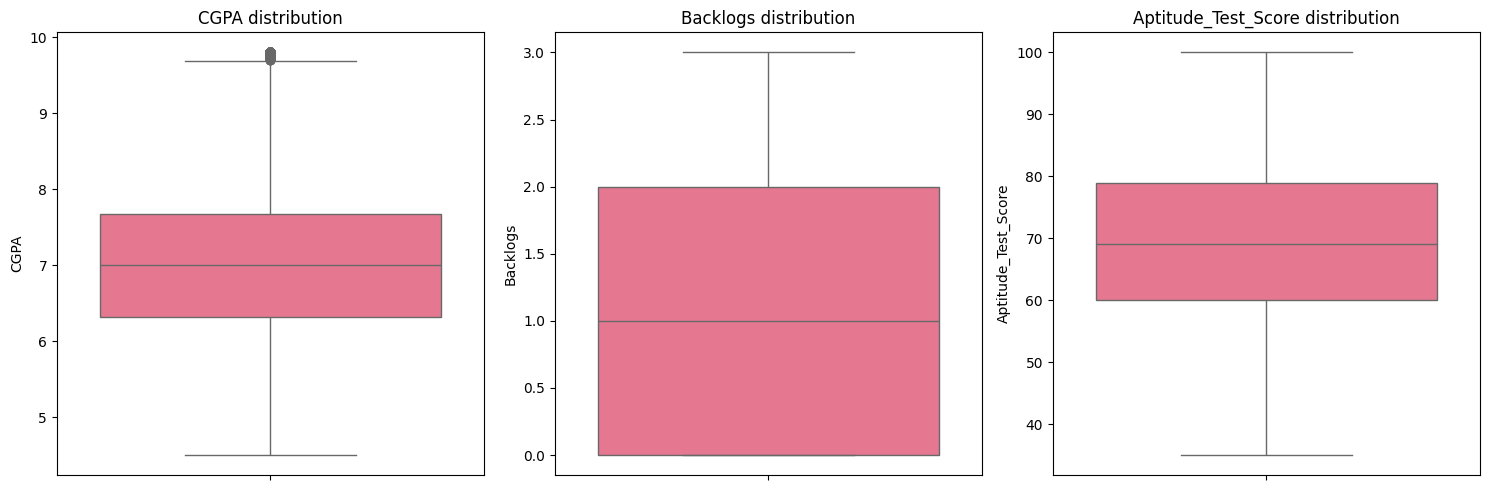

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, ['CGPA', 'Backlogs', 'Aptitude_Test_Score']):
    sns.boxplot(y=train[col], ax=ax, color='#F76587')
    ax.set_title(f'{col} distribution')
plt.tight_layout()
plt.show()

As it is already visible, There are quite a few outliers in the CGPA graph and it appears that there are none in the other two though it is better to look at the mathematics instead of trying to guess from the plot.


To get the actual numbers we will now perform some statistical calculations:

In [18]:
def iqr_bounds(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    return lower, upper

for col in ['CGPA', 'Backlogs', 'Aptitude_Test_Score']:
    lower, upper = iqr_bounds(train[col])
    n_outliers = ((train[col] < lower) | (train[col] > upper)).sum()
    print(f"{col}: valid range [{lower:.2f}, {upper:.2f}], "
          f"{n_outliers} outlier rows ({100*n_outliers/len(train):.2f}%)")

CGPA: valid range [4.30, 9.70], 153 outlier rows (0.34%)
Backlogs: valid range [-3.00, 5.00], 0 outlier rows (0.00%)
Aptitude_Test_Score: valid range [31.50, 107.50], 0 outlier rows (0.00%)


With this it becomes clear that there are infact outliers only in CGPA, but they are not a lot(0.34%).
As,
1. there are not that many outliers, these wont contribute to any major trouble while training models.
2. but also these outliers also pose to be important, as the IQR is 4.30-9.70, outliers are either above 9.70 - high performers, or below 4.30 - struggling students, both of these categories are equally important to access and train the model around.

There is also an possibility that the outliers are invalid (less than minimum allowed value or more than maximum allowed value) so rule this out we also looked at the minimum and maximum of each of these categories:

In [19]:
print("CGPA range:", train['CGPA'].min(), train['CGPA'].max())
print("Backlogs range:", train['Backlogs'].min(), train['Backlogs'].max())
print("Aptitude range:", train['Aptitude_Test_Score'].min(), train['Aptitude_Test_Score'].max())

CGPA range: 4.5 9.8
Backlogs range: 0 3
Aptitude range: 35 100


these are all fair and in range, hence this possibility is ruled out.

##Saving cleaned data

In [20]:
train.to_csv('train_cleaned.csv', index=False)
test.to_csv('test_cleaned.csv', index=False)

>side note: Student_ID is a single coloumn which doesn't hold any information on a student which can be used to predict if they will be placed or not; this is purely a coloumn which is more similar to a serial number coloumn. hence it is important that this does not ends up influincing any training model - it can very easily produce pseudo correlation between student_ID and chances of getting placed in tree models. to avoid this in later stages we will be sure to exclude it from X matrix before model training.

In [21]:
# NOTE: Student_ID must be excluded from X before model training —
# it is a row identifier with no predictive meaning; including it risks
# spurious high-cardinality splits in tree-based models (overfitting risk).

#Feature Engineering